### **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
from prophet import Prophet
import logging
from sqlalchemy import text
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

print("Library Sukses di Import")

Library Sukses di Import


c:\Users\ekopr\.conda\envs\smart_pharma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **2. Loading Data**

In [2]:
# setup, load ulang data pergerakan stok level harian
# (sengaja diulang dari notebook EDA, karena notebook ini fokus khusus
# forecasting, akan dirapikan jadi modul bersama nanti pas konversi ke .py)

load_dotenv()
db_url = os.getenv("GOLD_DATABASE_URL")
engine = create_engine(db_url)

query = """
SELECT 
    f.obat_id, o.nama_generik, o.obat_kode,
    f.gudang_id, g.nama AS nama_gudang,
    d.tanggal, f.jumlah_keluar
FROM gold.fact_stock_movement f
JOIN gold.dim_obat o ON f.obat_id = o.obat_id
JOIN gold.dim_gudang g ON f.gudang_id = g.gudang_id
JOIN gold.dim_waktu d ON f.tanggal_id = d.tanggal_id
ORDER BY d.tanggal
"""

df = pd.read_sql(query, engine)
df["tanggal"] = pd.to_datetime(df["tanggal"])
df = df.drop_duplicates()

# agregasi ke level harian per kombinasi obat-gudang
demand_harian = (
    df.groupby(["obat_id", "nama_generik", "gudang_id", "nama_gudang", "tanggal"])
    .agg(jumlah_keluar=("jumlah_keluar", "sum"))
    .reset_index()
)

# lengkapi kalender penuh, isi nol untuk hari tanpa transaksi
tanggal_lengkap = pd.date_range(df["tanggal"].min(), df["tanggal"].max(), freq="D")
daftar_lengkap = []
for (obat_id, nama_generik, gudang_id, nama_gudang), grup in demand_harian.groupby(
    ["obat_id", "nama_generik", "gudang_id", "nama_gudang"]
):
    grup_lengkap = (
        grup.set_index("tanggal")["jumlah_keluar"]
        .reindex(tanggal_lengkap)
        .fillna(0)
        .rename_axis("tanggal")
        .reset_index()
    )
    grup_lengkap["obat_id"] = obat_id
    grup_lengkap["nama_generik"] = nama_generik
    grup_lengkap["gudang_id"] = gudang_id
    grup_lengkap["nama_gudang"] = nama_gudang
    daftar_lengkap.append(grup_lengkap)

demand_harian_lengkap = pd.concat(daftar_lengkap, ignore_index=True)
print(f"Jumlah baris demand harian lengkap: {len(demand_harian_lengkap)}")
print(f"Jumlah kombinasi obat-gudang: {demand_harian_lengkap.groupby(['obat_id','gudang_id']).ngroups}")

Jumlah baris demand harian lengkap: 58480
Jumlah kombinasi obat-gudang: 80


In [3]:
# split berbasis waktu, 60 hari terakhir jadi test, sisanya training
# TIDAK BOLEH pakai split acak seperti klasifikasi kemarin, time series
# harus dipotong berurutan supaya tidak mengintip masa depan
HARI_TEST = 60
tanggal_batas = demand_harian_lengkap["tanggal"].max() - pd.Timedelta(days=HARI_TEST)

data_train = demand_harian_lengkap[demand_harian_lengkap["tanggal"] <= tanggal_batas].copy()
data_test = demand_harian_lengkap[demand_harian_lengkap["tanggal"] > tanggal_batas].copy()

print(f"Tanggal batas split: {tanggal_batas.date()}")
print(f"Jumlah baris training: {len(data_train)}")
print(f"Jumlah baris test    : {len(data_test)}")

Tanggal batas split: 2026-05-28
Jumlah baris training: 53680
Jumlah baris test    : 4800


In [4]:
# cell 3: baseline seasonal naive (lag-7), wajib ada sebelum model asli
# tebak demand hari ini = demand di hari yang sama, seminggu sebelumnya
# ini baseline yang jujur untuk data dengan pola mingguan seperti punya kita
def hitung_mape_mae(aktual, prediksi):
    # MAPE cuma dihitung di hari dengan aktual > 0, karena pembagian nol
    # bikin metrik ini tidak terdefinisi, bukan salah kode
    mask_valid = aktual > 0
    mape = (np.abs((aktual[mask_valid] - prediksi[mask_valid]) / aktual[mask_valid])).mean() * 100
    mae = np.abs(aktual - prediksi).mean()
    jumlah_hari_nol_diabaikan = (~mask_valid).sum()
    return mape, mae, jumlah_hari_nol_diabaikan

hasil_baseline = []

for (obat_id, gudang_id), grup_test in data_test.groupby(["obat_id", "gudang_id"]):
    grup_lengkap_seri = demand_harian_lengkap[
        (demand_harian_lengkap["obat_id"] == obat_id) &
        (demand_harian_lengkap["gudang_id"] == gudang_id)
    ].sort_values("tanggal").reset_index(drop=True)

    prediksi_lag7 = grup_lengkap_seri.set_index("tanggal")["jumlah_keluar"].shift(7)
    prediksi_untuk_test = prediksi_lag7.reindex(grup_test["tanggal"]).values
    aktual_test = grup_test.sort_values("tanggal")["jumlah_keluar"].values

    mape, mae, hari_nol = hitung_mape_mae(aktual_test, prediksi_untuk_test)
    hasil_baseline.append({
        "obat_id": obat_id, "gudang_id": gudang_id,
        "mape": mape, "mae": mae, "hari_nol_diabaikan": hari_nol,
    })

ringkasan_baseline = pd.DataFrame(hasil_baseline)
print("Ringkasan baseline seasonal naive (lag-7), rata-rata seluruh kombinasi:")
print(f"MAPE rata-rata: {ringkasan_baseline['mape'].mean():.2f}%")
print(f"MAE rata-rata : {ringkasan_baseline['mae'].mean():.2f}")
print()
print("5 kombinasi obat-gudang dengan MAPE terburuk:")
print(ringkasan_baseline.sort_values("mape", ascending=False).head())

Ringkasan baseline seasonal naive (lag-7), rata-rata seluruh kombinasi:
MAPE rata-rata: 41.85%
MAE rata-rata : 7.14

5 kombinasi obat-gudang dengan MAPE terburuk:
    obat_id gudang_id       mape        mae  hari_nol_diabaikan
62  OBT0541      GD03  71.619303   4.083333                   0
17  OBT0221      GD02  67.365875   5.383333                   2
1   OBT0015      GD02  65.996293   2.850000                   2
3   OBT0015      GD04  65.381320   3.600000                   1
64  OBT0549      GD01  60.997632  10.100000                   2


### **3. Exploration Data Analysis (EDA)**

In [5]:
# redam log cmdstanpy/prophet yang berisik, supaya output notebook tidak
# penuh baris log teknis yang tidak relevan buat kita
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

11:38:48 - cmdstanpy - INFO - Chain [1] start processing
11:38:48 - cmdstanpy - INFO - Chain [1] done processing


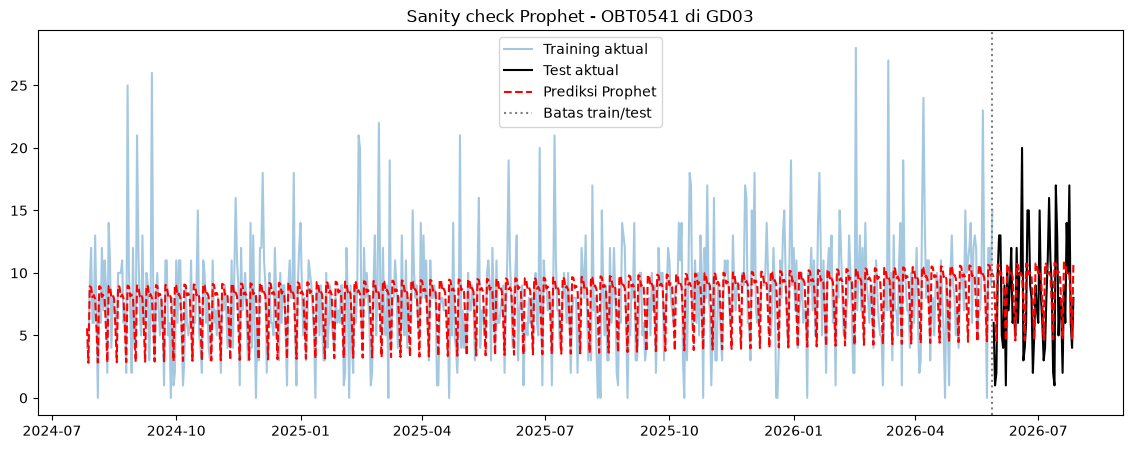

In [6]:
# sanity check di satu kombinasi dulu sebelum loop ke semua
obat_contoh, gudang_contoh = "OBT0541", "GD03"

grup_contoh = demand_harian_lengkap[
    (demand_harian_lengkap["obat_id"] == obat_contoh) &
    (demand_harian_lengkap["gudang_id"] == gudang_contoh)
].sort_values("tanggal")

train_contoh = grup_contoh[grup_contoh["tanggal"] <= tanggal_batas]
test_contoh = grup_contoh[grup_contoh["tanggal"] > tanggal_batas]

df_prophet_contoh = train_contoh.rename(
    columns={"tanggal": "ds", "jumlah_keluar": "y"}
)[["ds", "y"]]

model_contoh = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
)
model_contoh.fit(df_prophet_contoh)

future_contoh = model_contoh.make_future_dataframe(periods=HARI_TEST, freq="D")
forecast_contoh = model_contoh.predict(future_contoh)

# visualisasi, bandingkan prediksi dengan aktual di periode test
plt.figure(figsize=(14, 5))
plt.plot(train_contoh["tanggal"], train_contoh["jumlah_keluar"], label="Training aktual", alpha=0.4)
plt.plot(test_contoh["tanggal"], test_contoh["jumlah_keluar"], label="Test aktual", color="black")
plt.plot(forecast_contoh["ds"], forecast_contoh["yhat"], label="Prediksi Prophet", color="red", linestyle="--")
plt.axvline(tanggal_batas, color="gray", linestyle=":", label="Batas train/test")
plt.legend()
plt.title(f"Sanity check Prophet - {obat_contoh} di {gudang_contoh}")
plt.show()

### **4. Model Training**

In [7]:
# loop Prophet ke seluruh 80 kombinasi obat-gudang
# ini makan waktu beberapa menit, wajar, bukan macet
hasil_prophet = []
prediksi_semua = []

for (obat_id, gudang_id), grup in demand_harian_lengkap.groupby(["obat_id", "gudang_id"]):
    grup = grup.sort_values("tanggal")
    train_grup = grup[grup["tanggal"] <= tanggal_batas]
    test_grup = grup[grup["tanggal"] > tanggal_batas]

    df_prophet = train_grup.rename(columns={"tanggal": "ds", "jumlah_keluar": "y"})[["ds", "y"]]

    model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=HARI_TEST, freq="D")
    forecast = model.predict(future)

    prediksi_test = forecast.set_index("ds").loc[test_grup["tanggal"], "yhat"].values
    # demand tidak mungkin negatif, potong prediksi yang di bawah nol
    prediksi_test = np.clip(prediksi_test, 0, None)

    aktual_test = test_grup["jumlah_keluar"].values
    mape, mae, hari_nol = hitung_mape_mae(aktual_test, prediksi_test)

    hasil_prophet.append({
        "obat_id": obat_id, "gudang_id": gudang_id,
        "mape": mape, "mae": mae, "hari_nol_diabaikan": hari_nol,
    })

    hasil_simpan = test_grup[["obat_id", "gudang_id", "tanggal"]].copy()
    hasil_simpan["prediksi_permintaan"] = prediksi_test
    prediksi_semua.append(hasil_simpan)

ringkasan_prophet = pd.DataFrame(hasil_prophet)
prediksi_lengkap = pd.concat(prediksi_semua, ignore_index=True)

print("Ringkasan Prophet, rata-rata seluruh kombinasi:")
print(f"MAPE rata-rata: {ringkasan_prophet['mape'].mean():.2f}%")
print(f"MAE rata-rata : {ringkasan_prophet['mae'].mean():.2f}")

11:38:48 - cmdstanpy - INFO - Chain [1] start processing
11:38:48 - cmdstanpy - INFO - Chain [1] done processing
11:38:48 - cmdstanpy - INFO - Chain [1] start processing
11:38:48 - cmdstanpy - INFO - Chain [1] done processing
11:38:49 - cmdstanpy - INFO - Chain [1] start processing
11:38:49 - cmdstanpy - INFO - Chain [1] done processing
11:38:49 - cmdstanpy - INFO - Chain [1] start processing
11:38:49 - cmdstanpy - INFO - Chain [1] done processing
11:38:49 - cmdstanpy - INFO - Chain [1] start processing
11:38:49 - cmdstanpy - INFO - Chain [1] done processing
11:38:49 - cmdstanpy - INFO - Chain [1] start processing
11:38:49 - cmdstanpy - INFO - Chain [1] done processing
11:38:50 - cmdstanpy - INFO - Chain [1] start processing
11:38:50 - cmdstanpy - INFO - Chain [1] done processing
11:38:50 - cmdstanpy - INFO - Chain [1] start processing
11:38:50 - cmdstanpy - INFO - Chain [1] done processing
11:38:50 - cmdstanpy - INFO - Chain [1] start processing
11:38:50 - cmdstanpy - INFO - Chain [1]

Ringkasan Prophet, rata-rata seluruh kombinasi:
MAPE rata-rata: 29.21%
MAE rata-rata : 4.84


In [8]:
# perbandingan langsung baseline vs Prophet, per kombinasi dan rata-rata
perbandingan = ringkasan_baseline.merge(
    ringkasan_prophet, on=["obat_id", "gudang_id"], suffixes=("_baseline", "_prophet")
)
perbandingan["mape_membaik"] = perbandingan["mape_baseline"] > perbandingan["mape_prophet"]

print("Ringkasan rata-rata:")
print(f"MAPE baseline : {perbandingan['mape_baseline'].mean():.2f}%")
print(f"MAPE Prophet  : {perbandingan['mape_prophet'].mean():.2f}%")
print()
print(f"Jumlah kombinasi yang membaik dengan Prophet: {perbandingan['mape_membaik'].sum()} dari {len(perbandingan)}")
print()
print("5 kombinasi dengan perbaikan MAPE terbesar:")
print(
    perbandingan.assign(selisih=perbandingan["mape_baseline"] - perbandingan["mape_prophet"])
    .sort_values("selisih", ascending=False)
    .head()[["obat_id", "gudang_id", "mape_baseline", "mape_prophet", "selisih"]]
)

Ringkasan rata-rata:
MAPE baseline : 41.85%
MAPE Prophet  : 29.21%

Jumlah kombinasi yang membaik dengan Prophet: 79 dari 80

5 kombinasi dengan perbaikan MAPE terbesar:
    obat_id gudang_id  mape_baseline  mape_prophet    selisih
79  OBT0658      GD04      58.256328     32.439440  25.816888
17  OBT0221      GD02      67.365875     42.708279  24.657596
51  OBT0476      GD04      55.219933     31.325798  23.894135
13  OBT0132      GD02      54.866126     31.021022  23.845105
63  OBT0541      GD04      55.328112     31.628525  23.699587


#### 4.1 Menambahkan Tanggal Masa Depan

In [9]:
# cek dan perluas dim_waktu untuk mencakup tanggal masa depan
HARI_FORECAST_KE_DEPAN = 30  # kira-kira di tengah siklus kedatangan batch (20-40 hari)

tanggal_terakhir = demand_harian_lengkap["tanggal"].max()
tanggal_masa_depan = pd.date_range(
    tanggal_terakhir + pd.Timedelta(days=1), periods=HARI_FORECAST_KE_DEPAN, freq="D"
)

dim_waktu_ada = pd.read_sql("SELECT tanggal_id, tanggal FROM gold.dim_waktu", engine)
dim_waktu_ada["tanggal"] = pd.to_datetime(dim_waktu_ada["tanggal"])

tanggal_belum_ada = tanggal_masa_depan[~tanggal_masa_depan.isin(dim_waktu_ada["tanggal"])]

print(f"Tanggal masa depan yang dibutuhkan  : {len(tanggal_masa_depan)}")
print(f"Tanggal yang belum ada di dim_waktu : {len(tanggal_belum_ada)}")

Tanggal masa depan yang dibutuhkan  : 30
Tanggal yang belum ada di dim_waktu : 0


In [10]:
# kalau memang belum ada, generate baris dim_waktu baru dan insert
nama_hari_indonesia = {
    "Monday": "Senin", "Tuesday": "Selasa", "Wednesday": "Rabu",
    "Thursday": "Kamis", "Friday": "Jumat", "Saturday": "Sabtu", "Sunday": "Minggu",
}

if len(tanggal_belum_ada) > 0:
    dim_waktu_baru = pd.DataFrame({"tanggal": tanggal_belum_ada})
    dim_waktu_baru["tanggal_id"] = dim_waktu_baru["tanggal"].dt.strftime("%Y%m%d").astype(int)
    dim_waktu_baru["hari"] = dim_waktu_baru["tanggal"].dt.day_name().map(nama_hari_indonesia)
    dim_waktu_baru["bulan"] = dim_waktu_baru["tanggal"].dt.month
    dim_waktu_baru["tahun"] = dim_waktu_baru["tanggal"].dt.year
    dim_waktu_baru["is_weekend"] = dim_waktu_baru["tanggal"].dt.dayofweek.isin([5, 6])

    dim_waktu_baru = dim_waktu_baru[["tanggal_id", "tanggal", "hari", "bulan", "tahun", "is_weekend"]]
    dim_waktu_baru.to_sql("dim_waktu", engine, schema="gold", if_exists="append", index=False)
    print(f"Berhasil menambahkan {len(dim_waktu_baru)} baris baru ke gold.dim_waktu")
else:
    print("Semua tanggal masa depan sudah tersedia di dim_waktu, tidak perlu insert")

# ambil ulang dim_waktu lengkap (lama + baru) untuk mapping tanggal_id nanti
dim_waktu_lengkap = pd.read_sql("SELECT tanggal_id, tanggal FROM gold.dim_waktu", engine)
dim_waktu_lengkap["tanggal"] = pd.to_datetime(dim_waktu_lengkap["tanggal"])

Semua tanggal masa depan sudah tersedia di dim_waktu, tidak perlu insert


#### 4.2 Model Training Tanggal Masa Depan

In [11]:
# fit ulang Prophet pakai SELURUH histori (bukan cuma sampai batas
# evaluasi kemarin), lalu forecast maju ke depan
# ini model yang benar-benar dipakai untuk procurement, beda tujuan dari
# model evaluasi sebelumnya yang sengaja disisakan data buat dites
hasil_forecast_final = []

for (obat_id, gudang_id), grup in demand_harian_lengkap.groupby(["obat_id", "gudang_id"]):
    grup = grup.sort_values("tanggal")
    df_prophet_final = grup.rename(columns={"tanggal": "ds", "jumlah_keluar": "y"})[["ds", "y"]]

    model_final_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    model_final_prophet.fit(df_prophet_final)

    future_final = model_final_prophet.make_future_dataframe(periods=HARI_FORECAST_KE_DEPAN, freq="D")
    forecast_final = model_final_prophet.predict(future_final)

    # ambil cuma bagian masa depan, bukan yang menimpa periode historis
    forecast_masa_depan = forecast_final[forecast_final["ds"] > tanggal_terakhir].copy()
    forecast_masa_depan["yhat"] = np.clip(forecast_masa_depan["yhat"], 0, None)

    hasil_simpan = pd.DataFrame({
        "obat_id": obat_id,
        "gudang_id": gudang_id,
        "tanggal": forecast_masa_depan["ds"].values,
        "prediksi_permintaan": forecast_masa_depan["yhat"].values,
    })
    hasil_forecast_final.append(hasil_simpan)

forecast_produksi = pd.concat(hasil_forecast_final, ignore_index=True)
print(f"Total baris forecast masa depan: {len(forecast_produksi)}")
print(f"Rentang tanggal forecast: {forecast_produksi['tanggal'].min()} sampai {forecast_produksi['tanggal'].max()}")

11:39:07 - cmdstanpy - INFO - Chain [1] start processing
11:39:07 - cmdstanpy - INFO - Chain [1] done processing
11:39:08 - cmdstanpy - INFO - Chain [1] start processing
11:39:08 - cmdstanpy - INFO - Chain [1] done processing
11:39:08 - cmdstanpy - INFO - Chain [1] start processing
11:39:08 - cmdstanpy - INFO - Chain [1] done processing
11:39:08 - cmdstanpy - INFO - Chain [1] start processing
11:39:08 - cmdstanpy - INFO - Chain [1] done processing
11:39:08 - cmdstanpy - INFO - Chain [1] start processing
11:39:08 - cmdstanpy - INFO - Chain [1] done processing
11:39:09 - cmdstanpy - INFO - Chain [1] start processing
11:39:09 - cmdstanpy - INFO - Chain [1] done processing
11:39:09 - cmdstanpy - INFO - Chain [1] start processing
11:39:09 - cmdstanpy - INFO - Chain [1] done processing
11:39:09 - cmdstanpy - INFO - Chain [1] start processing
11:39:09 - cmdstanpy - INFO - Chain [1] done processing
11:39:09 - cmdstanpy - INFO - Chain [1] start processing
11:39:09 - cmdstanpy - INFO - Chain [1]

Total baris forecast masa depan: 2400
Rentang tanggal forecast: 2026-07-28 00:00:00 sampai 2026-08-26 00:00:00


### **5. Eksport Prediksi ke Database gold.pred_demand_forecast**

In [12]:
# gabungkan dengan tanggal_id, lalu tulis ke gold.pred_demand_forecast
forecast_produksi = forecast_produksi.merge(dim_waktu_lengkap, on="tanggal", how="left")

jumlah_gagal_mapping = forecast_produksi["tanggal_id"].isnull().sum()
print(f"Jumlah baris gagal mapping tanggal_id: {jumlah_gagal_mapping}")

if jumlah_gagal_mapping == 0:
    hasil_untuk_gold = forecast_produksi[["obat_id", "gudang_id", "tanggal_id", "prediksi_permintaan"]].copy()
    hasil_untuk_gold["dibuat_pada"] = datetime.now(timezone.utc)

    with engine.begin() as koneksi:
        koneksi.execute(text("TRUNCATE TABLE gold.pred_demand_forecast"))

    hasil_untuk_gold.to_sql(
        "pred_demand_forecast", engine, schema="gold", if_exists="append", index=False,
    )
    print(f"Berhasil menulis {len(hasil_untuk_gold)} baris ke gold.pred_demand_forecast")
else:
    print("Ada baris yang gagal mapping tanggal_id, cek dulu sebelum menulis ke gold")

Jumlah baris gagal mapping tanggal_id: 0
Berhasil menulis 2400 baris ke gold.pred_demand_forecast


In [13]:
# perluas skema gold.pred_demand_forecast dengan kolom interval
# keputusan sadar untuk extend sekarang, sebelum Recommendation Agent dibangun,
# supaya tidak perlu re-fit ulang 80 model Prophet di kemudian hari
with engine.begin() as koneksi:
    koneksi.execute(text("""
        ALTER TABLE gold.pred_demand_forecast
        ADD COLUMN IF NOT EXISTS prediksi_permintaan_bawah NUMERIC,
        ADD COLUMN IF NOT EXISTS prediksi_permintaan_atas NUMERIC
    """))

print("Kolom interval berhasil ditambahkan ke gold.pred_demand_forecast")

Kolom interval berhasil ditambahkan ke gold.pred_demand_forecast


### **6. Model Training dengan yhat_lower dan yhat_upper**

In [14]:
# ulangi loop forecast, kali ini sertakan yhat_lower dan yhat_upper
# logikanya sama persis dengan cell 10, cuma tambah dua kolom
hasil_forecast_final = []

for (obat_id, gudang_id), grup in demand_harian_lengkap.groupby(["obat_id", "gudang_id"]):
    grup = grup.sort_values("tanggal")
    df_prophet_final = grup.rename(columns={"tanggal": "ds", "jumlah_keluar": "y"})[["ds", "y"]]

    model_final_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    model_final_prophet.fit(df_prophet_final)

    future_final = model_final_prophet.make_future_dataframe(periods=HARI_FORECAST_KE_DEPAN, freq="D")
    forecast_final = model_final_prophet.predict(future_final)

    forecast_masa_depan = forecast_final[forecast_final["ds"] > tanggal_terakhir].copy()
    # interval bawah tidak boleh negatif juga, sama alasannya dengan yhat
    forecast_masa_depan["yhat"] = np.clip(forecast_masa_depan["yhat"], 0, None)
    forecast_masa_depan["yhat_lower"] = np.clip(forecast_masa_depan["yhat_lower"], 0, None)
    forecast_masa_depan["yhat_upper"] = np.clip(forecast_masa_depan["yhat_upper"], 0, None)

    hasil_simpan = pd.DataFrame({
        "obat_id": obat_id,
        "gudang_id": gudang_id,
        "tanggal": forecast_masa_depan["ds"].values,
        "prediksi_permintaan": forecast_masa_depan["yhat"].values,
        "prediksi_permintaan_bawah": forecast_masa_depan["yhat_lower"].values,
        "prediksi_permintaan_atas": forecast_masa_depan["yhat_upper"].values,
    })
    hasil_forecast_final.append(hasil_simpan)

forecast_produksi = pd.concat(hasil_forecast_final, ignore_index=True)
print(f"Total baris forecast masa depan: {len(forecast_produksi)}")

11:39:27 - cmdstanpy - INFO - Chain [1] start processing
11:39:27 - cmdstanpy - INFO - Chain [1] done processing
11:39:27 - cmdstanpy - INFO - Chain [1] start processing
11:39:27 - cmdstanpy - INFO - Chain [1] done processing
11:39:28 - cmdstanpy - INFO - Chain [1] start processing
11:39:28 - cmdstanpy - INFO - Chain [1] done processing
11:39:28 - cmdstanpy - INFO - Chain [1] start processing
11:39:28 - cmdstanpy - INFO - Chain [1] done processing
11:39:28 - cmdstanpy - INFO - Chain [1] start processing
11:39:28 - cmdstanpy - INFO - Chain [1] done processing
11:39:28 - cmdstanpy - INFO - Chain [1] start processing
11:39:28 - cmdstanpy - INFO - Chain [1] done processing
11:39:29 - cmdstanpy - INFO - Chain [1] start processing
11:39:29 - cmdstanpy - INFO - Chain [1] done processing
11:39:29 - cmdstanpy - INFO - Chain [1] start processing
11:39:29 - cmdstanpy - INFO - Chain [1] done processing
11:39:29 - cmdstanpy - INFO - Chain [1] start processing
11:39:29 - cmdstanpy - INFO - Chain [1]

Total baris forecast masa depan: 2400


### **7. Eksport Kembali Prediksi ke Database gold.pred_demand_forecast**

In [15]:
# tulis ulang ke gold.pred_demand_forecast, kali ini dengan interval
forecast_produksi = forecast_produksi.merge(dim_waktu_lengkap, on="tanggal", how="left")

jumlah_gagal_mapping = forecast_produksi["tanggal_id"].isnull().sum()
print(f"Jumlah baris gagal mapping tanggal_id: {jumlah_gagal_mapping}")

if jumlah_gagal_mapping == 0:
    hasil_untuk_gold = forecast_produksi[[
        "obat_id", "gudang_id", "tanggal_id",
        "prediksi_permintaan", "prediksi_permintaan_bawah", "prediksi_permintaan_atas",
    ]].copy()
    hasil_untuk_gold["dibuat_pada"] = datetime.now(timezone.utc)

    with engine.begin() as koneksi:
        koneksi.execute(text("TRUNCATE TABLE gold.pred_demand_forecast"))

    hasil_untuk_gold.to_sql(
        "pred_demand_forecast", engine, schema="gold", if_exists="append", index=False,
    )
    print(f"Berhasil menulis ulang {len(hasil_untuk_gold)} baris dengan kolom interval")
else:
    print("Ada baris gagal mapping, cek dulu sebelum menulis ke gold")

Jumlah baris gagal mapping tanggal_id: 0
Berhasil menulis ulang 2400 baris dengan kolom interval
